https://refubium.fu-berlin.de/bitstream/handle/fub188/3427/02_Chapter1.pdf?sequence=3&save=y

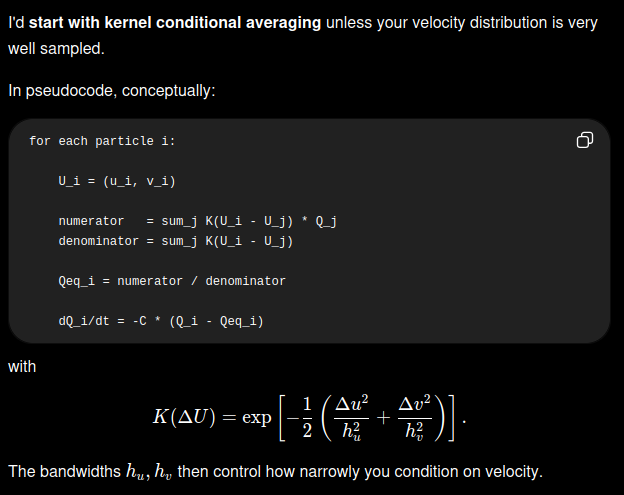

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import Models.Gas as Gas
import importlib
importlib.reload(Gas)
from Models.Gas import *
import os
from datetime import datetime

In [5]:

Rin = 10*1e-6
Rout = 0.1*1e-6

Rmin = 0.7*1e-6


dt = 0.001



        
#test run bare and animate
gas = Gas(nParticles=10000, box_size=1.0, dt = dt)
gas.initialize_thermo(Ct=10., Cq=10., Tin=272., Tout=274., QinCoeff = 1.01, QoutCoeff = 0.9, Rin = Rin, Rout = Rout)
gas.update_thermo()
posHist = gas.run_bare(nSteps=100)
ani = gas.animate(posHist)
#HTML(ani.to_jshtml())
        


Initializing R
Done


100%|██████████| 100/100 [00:00<00:00, 2566.27it/s]


Initializing R
Done


100%|██████████| 50000/50000 [08:03<00:00, 103.48it/s]


Initializing R
Done


100%|██████████| 50000/50000 [15:41<00:00, 53.10it/s]


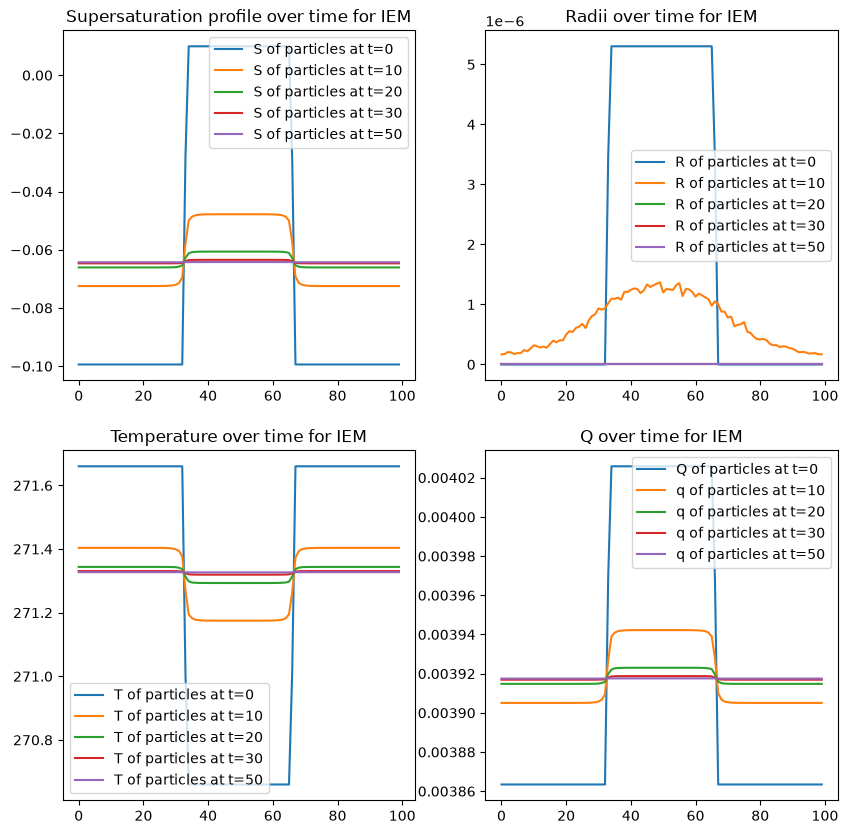

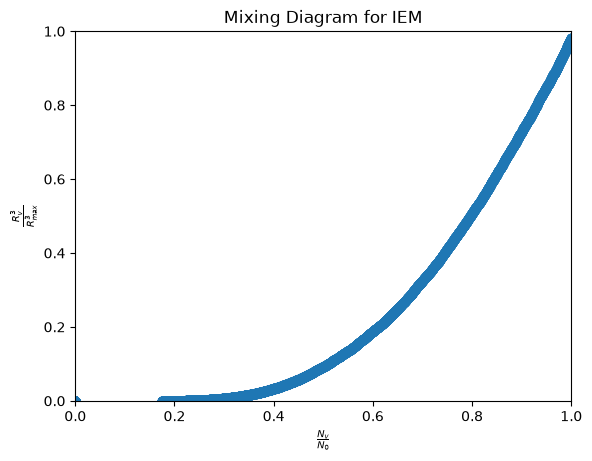

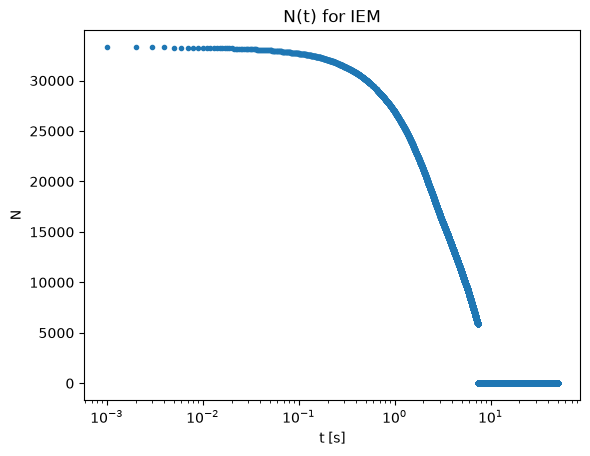

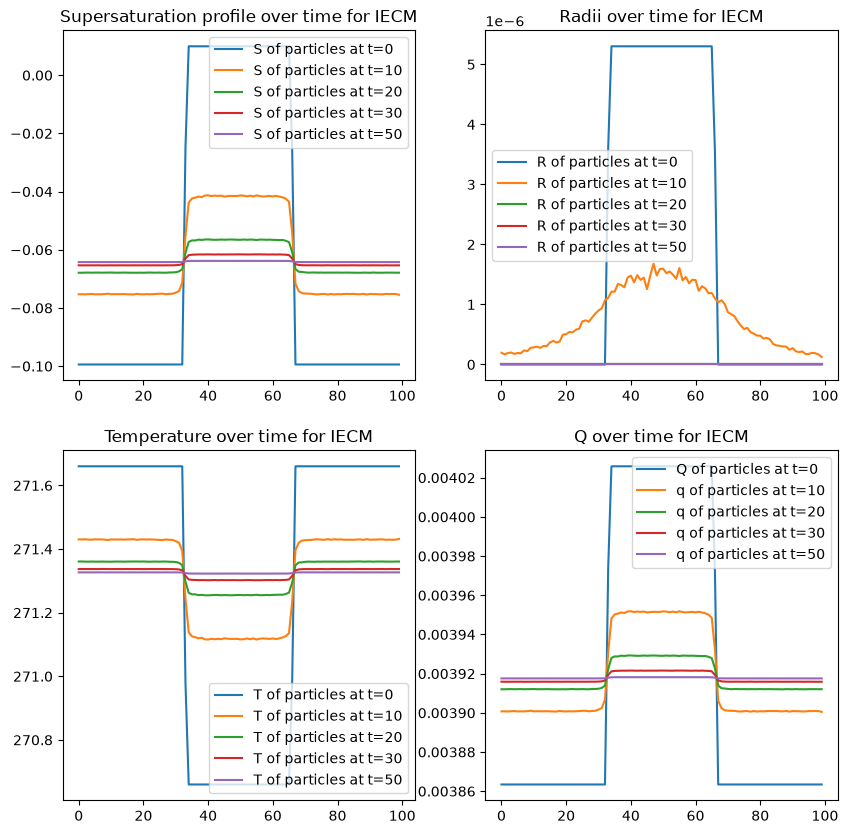

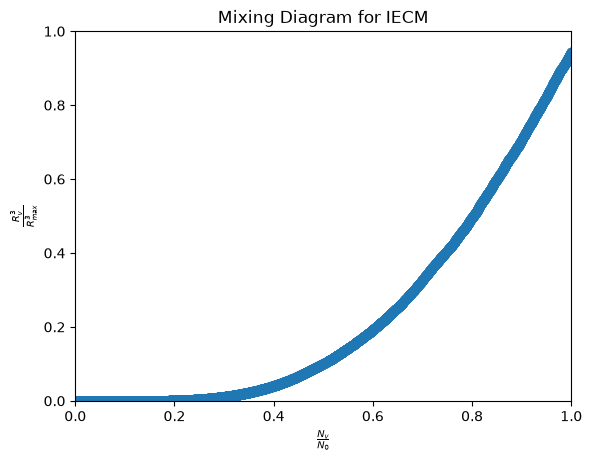

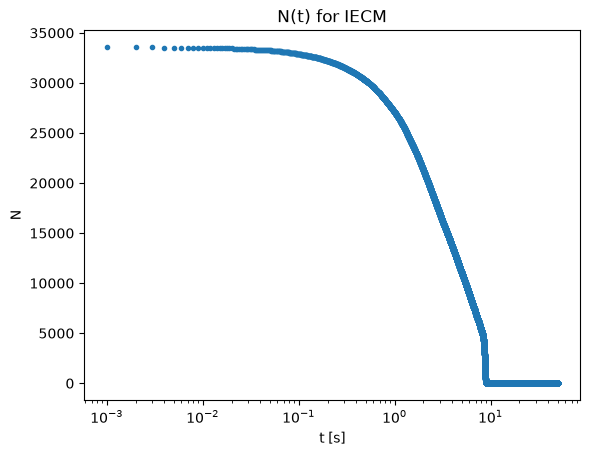

In [9]:
def plot_history(history,radii,ts,qs, mode,save=False):
    fig, ax = plt.subplots(2,2,figsize = [10,10])
    ax[0,0].plot(history[0,:], label="S of particles at t=0")
    ax[0,0].plot(history[10,:], label="S of particles at t=10")
    ax[0,0].plot(history[20,:], label="S of particles at t=20")
    ax[0,0].plot(history[30,:], label="S of particles at t=30")
    ax[0,0].plot(history[50,:], label="S of particles at t=50")
    ax[0,0].set_title(f"Supersaturation profile over time for {mode}")
    ax[0,0].legend()

    ax[0,1].plot(radii[0,:], label="R of particles at t=0")
    ax[0,1].plot(radii[10,:], label="R of particles at t=10")
    ax[0,1].plot(radii[20,:], label="R of particles at t=20")
    ax[0,1].plot(radii[30,:], label="R of particles at t=30")
    ax[0,1].plot(radii[50,:], label="R of particles at t=50")
    ax[0,1].set_title(f"Radii over time for {mode}")
    ax[0,1].legend()

    ax[1,0].plot(ts[0,:], label="T of particles at t=0")
    ax[1,0].plot(ts[10,:], label="T of particles at t=10")
    ax[1,0].plot(ts[20,:], label="T of particles at t=20")
    ax[1,0].plot(ts[30,:], label="T of particles at t=30")
    ax[1,0].plot(ts[50,:], label="T of particles at t=50")
    ax[1,0].set_title(f"Temperature over time for {mode}")
    ax[1,0].legend()

    ax[1,1].plot(qs[0,:], label="Q of particles at t=0")
    ax[1,1].plot(qs[10,:], label="q of particles at t=10")
    ax[1,1].plot(qs[20,:], label="q of particles at t=20")
    ax[1,1].plot(qs[30,:], label="q of particles at t=30")
    ax[1,1].plot(qs[50,:], label="q of particles at t=50")
    ax[1,1].set_title(f"Q over time for {mode}")
    ax[1,1].legend()
    if save:
        plt.savefig(f"{save}/"+f"profiles_{mode}.png")
        np.savetxt(f"{save}/"+f"Shist_{mode}.txt", history)
        np.savetxt(f"{save}/"+f"Rhist_{mode}.txt", radii)
        np.savetxt(f"{save}/"+f"Thist_{mode}.txt", ts)
        np.savetxt(f"{save}/"+f"qhist_{mode}.txt", qs)


def plot_mixing(Rs, Ns,mixing_mode,save = False):
    fig, ax = plt.subplots()
    ax.scatter(Ns,Rs)
    ax.set_xlabel(r"$\frac{N_v}{N_0}$")
    ax.set_ylabel(r"$\frac{R_v^3}{R_{max}^3}$")
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_title(f"Mixing Diagram for {mixing_mode}")
    if save:
        plt.savefig(f"{save}/"+f"MixDiagram_{mixing_mode}.png")
        np.savetxt(f"{save}/"+f"RT_{mixing_mode}.txt", Rs)

def plot_N_history(Ns, mixing_mode,save=False):
    ts = np.arange(len(Ns))*dt

    fig,ax = plt.subplots()

    ax.scatter(ts,Ns,marker='.')
    ax.set_xlabel("t [s]")
    ax.set_ylabel("N")
    ax.set_xscale("log")
    ax.set_title(f"N(t) for {mixing_mode}")
    if save:
        plt.savefig(f"{save}/"+f"NT_{mixing_mode}.png")
        np.savetxt(f"{save}/"+f"NT_{mixing_mode}.txt", Ns)

def plot_and_save(S_hist,R_hist,T_hist,q_hist, R3, N3, Ns, mixing_mode):
    now = datetime.now()
    base = "./output/" + now.strftime("%d-%m-%Y")

    i = 0
    folder = base

    while os.path.exists(folder):
        folder = f"{base}_{i}"
        i += 1

    os.mkdir(folder)
    plot_history(S_hist,R_hist,T_hist,q_hist, mode = mixing_mode, save = folder)
    plot_mixing(R3, N3, mixing_mode, save = folder)
    plot_N_history(Ns, mixing_mode,save = folder)

def run_simulation(nOfParticles, nOfSteps, Cq, Ct, mode = "zones", mixing_mode = "IEM", save = True):
    Tout = T00-1.5
    Tin = T00-2.5
    dt = 1e-3
    nBins = 100
    gas = Gas(nParticles=nOfParticles, dt = dt, box_size=1.0)
    gas.initialize_thermo(Ct=Ct, Cq=Cq, Rin = Rin, Rout = Rout, Tin=Tin, Tout=Tout, QinCoeff = 1.01, QoutCoeff = 0.9)
    N0 = np.sum(gas.R>Rmin)
    Rmax = 0
    S_hist = np.zeros((100, nBins))
    R_hist = np.zeros_like(S_hist)
    q_hist = np.zeros_like(S_hist)
    T_hist = np.zeros_like(S_hist)
    Ns = np.zeros(nOfSteps)
    Rs = np.zeros_like(Ns)
    ix = np.floor(gas.positions[:,0] * nBins).astype(int)
    R_hist[0,:] = np.bincount(ix,weights=gas.R,minlength=nBins)/(nOfParticles/nBins)
    for i in tqdm(range(nOfSteps)):
        Ts, qs = gas.update_thermo(relaxation_mode=mode, mixing_mode=mixing_mode)

        S = superSat(gas.p, Ts, qs)
        if i % (nOfSteps//100) == 0:
            ix = np.floor(gas.positions[:,0] * nBins).astype(int)
            counts = np.bincount(ix, minlength=nBins)
            T_hist[i//(nOfSteps//100),:] = (
                np.bincount(ix, weights=gas.Ts, minlength=nBins)
                / np.maximum(counts, 1)
            )

            q_hist[i//(nOfSteps//100),:] = (
                np.bincount(ix, weights=gas.qs, minlength=nBins)
                / np.maximum(counts, 1)
            )

            S_hist[i//(nOfSteps//100),:] = (
                np.bincount(ix, weights=S, minlength=nBins)
                / np.maximum(counts, 1)
            )

            R_hist[i//(nOfSteps//100),:] = (
                np.bincount(ix, weights=gas.R, minlength=nBins)
                / np.maximum(counts, 1)
            )
                        

        mask = (gas.positions[:,0] > gas.box_size/3) & (gas.positions[:,0] < 2*gas.box_size/3)

        Rs[i] = np.average(gas.R[mask])
        Ns[i] = np.sum(gas.R[mask]>Rmin)
        if np.max(gas.R) > Rmax:
            Rmax = np.max(gas.R)
        gas.update_positions()
    if save:
        plot_and_save(S_hist,R_hist,T_hist,q_hist, Rs**3/Rmax**3, Ns/N0, Ns, mixing_mode)
    else:
        plot_history(S_hist,R_hist,T_hist,q_hist, mode = mixing_mode)
        plot_mixing(Rs**3/Rmax**3, Ns/N0, mixing_mode)
        plot_N_history(Ns, mixing_mode)

#run_simulation(nOfParticles=10000, nOfSteps=10000, Cq=10, Ct=10)
#run_simulation(nOfParticles=10000, nOfSteps=50000, Cq=15, Ct=15s)
run_simulation(nOfParticles=100000, nOfSteps=50000, Cq=10, Ct=10,mode = "zones",mixing_mode="IEM")
run_simulation(nOfParticles=100000, nOfSteps=50000, Cq=10, Ct=10,mode = "zones",mixing_mode="IECM")

In [6]:
run_simulation(nOfParticles=10000, nOfSteps=100000, Cq=10, Ct=10)

 16%|█▌        | 15613/100000 [00:12<01:05, 1287.12it/s]


KeyboardInterrupt: 

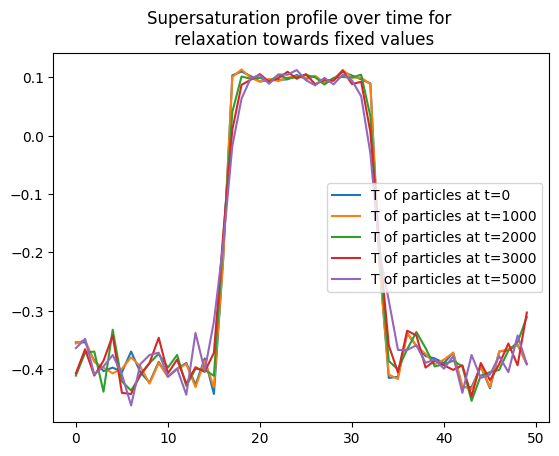

In [67]:
plt.plot(S_hist[0,:], label="T of particles at t=0")
plt.plot(S_hist[1,:], label="T of particles at t=1000")
plt.plot(S_hist[20,:], label="T of particles at t=2000")
plt.plot(S_hist[30,:], label="T of particles at t=3000")
plt.plot(S_hist[50,:], label="T of particles at t=5000")
plt.title("Supersaturation profile over time for \n relaxation towards fixed values")
plt.legend()

In [1]:
# def plot_history(history, mode, nOfSteps,Tin,Tout):
#     fig, ax = plt.subplots()
#     ax.vlines(0.33, np.min(history), np.max(history), colors='gray', linestyles='dashed')
#     ax.vlines(0.66, np.min(history), np.max(history), colors='gray', linestyles='dashed')
#     ax.plot(np.linspace(0, 1, 50), history[0,:],  label=f"S at t={nOfSteps//50*0}")
#     ax.plot(np.linspace(0, 1, 50), history[10,:], label=f"S at t={nOfSteps//50*10}")
#     ax.plot(np.linspace(0, 1, 50), history[20,:], label=f"S at t={nOfSteps//50*20}")
#     ax.plot(np.linspace(0, 1, 50), history[30,:], label=f"S at t={nOfSteps//50*30}")
#     ax.plot(np.linspace(0, 1, 50), history[50,:], label=f"S at t={nOfSteps//50*50}")
#     ax.text(0.1, 0.9, f"Tin={Tin}K,\n Tout={Tout}K", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
#     ax.set_title("Supersaturation profile over time for \n relaxation towards average" if mode == "average" else "Supersaturation profile over time for \n relaxation towards fixed")
#     ax.legend()
#     #save the plot
#     plt.savefig(f"profiles/supersaturation_profile_{mode}_{Tin}_{Tout}_2.png")

def run_simulation(nOfParticles, nOfSteps, Cq, Ct,TinC,ToutC, mode = "fixed"):
    Tout = T00+ToutC
    Tin = T00+TinC
    dt = 0.001
    gas = Gas(nParticles=nOfParticles, box_size=1.0)
    gas.initialize_thermo(Ct=Ct, Cq=Cq, Tin=Tin, Tout=Tout, QinCoeff = 1.01, QoutCoeff = 0.9)
    S_hist = np.zeros((100, 50))
    for i in tqdm(range(nOfSteps)):
        Ts, qs = gas.update_thermo(dt=dt, relaxation_mode=mode)
        S = superSat(gas.p, Ts, qs)
        ix = np.floor(gas.positions[:,0] * 50).astype(int)
        if i % (nOfSteps//100) == 0:
            S_hist[i//(nOfSteps//100),:] = np.bincount(ix, weights=S, minlength=50)/(nOfParticles/50)
        gas.update_positions(dt=dt)
    
    print(S_hist[0,:])
    plot_history(S_hist, mode = mode)
    
    return S_hist

"""S_hist1 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=10, ToutC=20, mode = "average")
S_hist2 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=10, ToutC=20, mode = "fixed")
S_hist3 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=2, ToutC=20, mode = "average")
S_hist4 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=2, ToutC=20, mode = "fixed")
S_hist5 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=18, ToutC=20, mode = "average")
S_hist6 = run_simulation(nOfParticles=100000, nOfSteps=10000, Cq=10, Ct=10, TinC=18, ToutC=20, mode = "fixed")
"""

"""np.savetxt("S_hist1_average_10_20.txt", S_hist1)
np.savetxt("S_hist2_fixed_10_20.txt", S_hist2)
np.savetxt("S_hist3_average_20_2.txt", S_hist3)
np.savetxt("S_hist4_fixed_20_2.txt", S_hist4)
np.savetxt("S_hist5_average_20_18.txt", S_hist5)
np.savetxt("S_hist6_fixed_20_18.txt", S_hist6)"""

baba = run_simulation(nOfParticles=30000, nOfSteps=1000, Cq=10, Ct=10, TinC=-2.5, ToutC=-1.5, mode = "zones")
np.savetxt("S_hist_average_20_2_v2.txt", baba)

NameError: name 'T00' is not defined

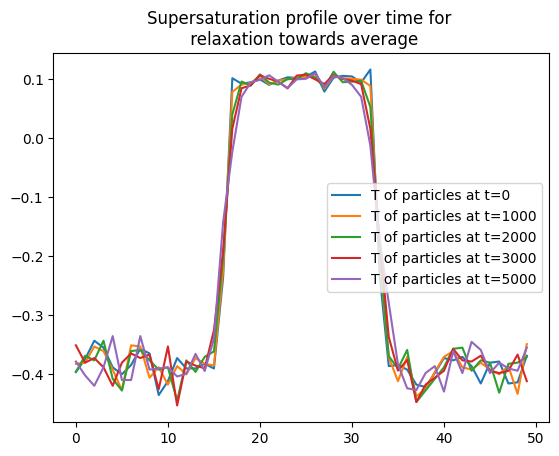

In [53]:
plt.plot(S_hist[0,:], label="T of particles at t=0")
plt.plot(S_hist[10,:], label="T of particles at t=1000")
plt.plot(S_hist[20,:], label="T of particles at t=2000")
plt.plot(S_hist[30,:], label="T of particles at t=3000")
plt.plot(S_hist[50,:], label="T of particles at t=5000")
plt.title("Supersaturation profile over time for \n relaxation towards average")
plt.legend()

In [11]:
nBins = 3
nSteps = 10000
NParticlesPerBin = np.zeros([nBins**2,nSteps])
print(NParticlesPerBin.shape)
posHist = np.zeros((2,nSteps))
U = np.zeros((N,2))
for i in tqdm(range(nSteps)):
    #hist = plt.hist2d(R[:,0], R[:,1], bins=nBins, range=[[0,L],[0,L]], cmap='plasma')
    for _ in range(1):
        R, U = step(R,U,0.1)
    #NParticlesPerBin[:,i] = hist[0].flatten()
    #NParticlesPerBin[:,i] = np.sum(R[:,0:1]//(L/nBins) == np.arange(nBins).reshape(1,-1),axis=1)[:,0] * nBins + np.sum(R[:,1:2]//(L/nBins) == np.arange(nBins).reshape(1,-1),axis=1)[:,0]   
    x,y = R[:,0], R[:,1]
    cell_x = np.floor(3 * x / L).astype(int)
    cell_y = np.floor(3 * y / L).astype(int)

    # Prevent edge-case overflow when x or y == L
    cell_x = np.clip(cell_x, 0, 2)
    cell_y = np.clip(cell_y, 0, 2)

    # Accumulate counts
    counts = np.zeros((3, 3), dtype=int)
    np.add.at(counts, (cell_x, cell_y), 1)
    NParticlesPerBin[:,i] = counts.flatten()
    posHist[:,i] = R[0,:]


    """edges = np.linspace(0, L, 4)  # 4 edges → 3 cells

    # Count particles per cell
    counts, xedges, yedges = np.histogram2d(x, y, bins=[edges, edges])

    NParticlesPerBin[:, i] = counts.flatten()"""


#Doesn't work very well
#plt.hist(NParticlesPerBin[0],bins = 10)

(9, 10000)


100%|██████████| 10000/10000 [05:07<00:00, 32.47it/s]


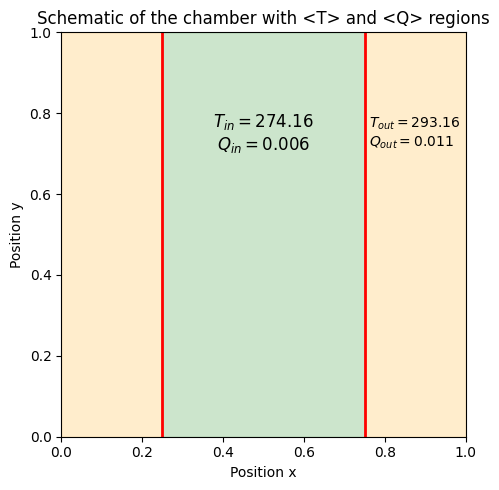

In [37]:
A = 275  # example value for T_in
B = 0.006  # example value for Q_in

fig, ax = plt.subplots(figsize=(5,5))

# Set axes limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Vertical red lines
ax.axvline(1/4, color='red', linewidth=2)
ax.axvline(3/4, color='red', linewidth=2)

# Green shaded region
ax.axvspan(1/4, 3/4, color='green', alpha=0.2)

#orange shaded regions
ax.axvspan(0, 1/4, color='orange', alpha=0.2)
ax.axvspan(3/4, 1, color='orange', alpha=0.2)


# Text in the middle
text = f"$T_{{in}} = {Tin}$\n$Q_{{in}} = {Qin:.3f}$"
ax.text(0.5, 0.75, text, ha='center', va='center', fontsize=12)

text2 = f"$T_{{out}} = {Tout}$\n$Q_{{out}} = {Qout:.3f}$"
ax.text(0.76, 0.75, text2, ha='left', va='center', fontsize=10)

# Make it look neat
ax.set_aspect('equal')
plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Schematic of the chamber with <T> and <Q> regions')
plt.tight_layout()
plt.savefig('chamber_schematic.png', dpi=300)
plt.show()


In [ ]:
#calculating S inside and ouside of the chamber at the end of the simulation
import numpy as np
import matplotlib.pyplot as plt
def analyse_S_hist(fileName):
    S_hist = np.loadtxt(fileName)
    S_final = S_hist[-1,:]
    print(S_hist.shape)
    #plt.plot(S_hist[-1, :], label=f'S at t={i*10}')
    #plt.legend()
    #plt.show()

    Average_S_inside = np.mean(S_final[16:34])
    Average_S_outside = np.mean(np.concatenate([S_final[:5], S_final[44:]]))
    #print(f"Average S inside the chamber: {Average_S_inside:.4f}")
    #print(f"Average S outside the chamber: {Average_S_outside:.4f}")

    Tin = float(fileName.split("_")[3].replace(".txt",""))
    Tout = float(fileName.split("_")[4].replace(".txt",""))
    # print(Tin,Tout)
    Tin , Tout = np.min([Tin, Tout]), np.max([Tin, Tout])
    
    # print(Tin, Tout)
    return [(Tin, Tout), (Average_S_inside, Average_S_outside)]

#analyse every file in SHIST folder with average relaxation mode
averages = []
import os
for file in os.listdir("SHIST"):
    if file.endswith(".txt") and "average" in file:
        print(f"Analyzing {file}...")
        averages.append(analyse_S_hist(os.path.join("SHIST", file)))



Analyzing S_hist_average_20_18.txt...
(100, 50)
20.0 18.0
18.0 20.0
Analyzing S_hist_average_10_20.txt...
(100, 50)
10.0 20.0
10.0 20.0
Analyzing S_hist_average_20_2.txt...
(100, 50)
20.0 2.0
2.0 20.0


Hallucinated averaging of q over a domain V <U|V>

100%|██████████| 100/100 [00:06<00:00, 16.50it/s]

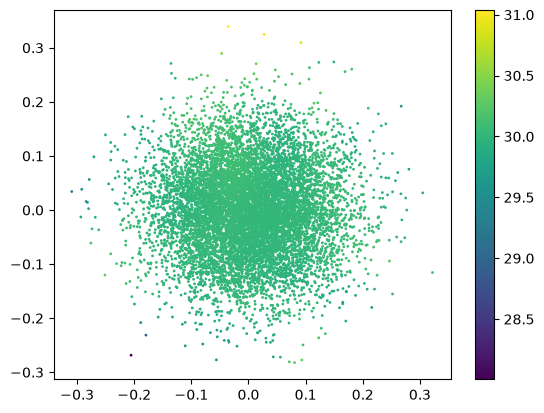

In [32]:
import numpy as np
from scipy.ndimage import gaussian_filter
nTest = 1000000
vTest = np.random.normal(0, sigma_u, (nTest, 2))
qTest = np.random.choice([10.,50.],size = nTest)


def average_by_velocity_grid(velocities, q_values, grid_size=128, sigma_cells=2.0):
    """
    Fast estimation of velocity-domain averages using 2D grid binning and Gaussian blurring.
    
    Parameters:
    -----------
    velocities : np.ndarray
        Shape (nParticles, 2), the velocity vectors.
    q_values : np.ndarray
        Shape (nParticles,), the parameter to average.
    grid_size : int
        Resolution of the velocity grid (e.g., 64x64 or 128x128). Higher means more localized.
    sigma_cells : float
        The standard deviation of the Gaussian kernel, measured in grid cells.
        
    Returns:
    --------
    q_avg_grid : np.ndarray
        A (grid_size, grid_size) map of the averaged q parameter.
    x_edges, y_edges : np.ndarray
        The velocity boundary markers for the grid axes.
    """
    # 1. Dynamically find velocity bounds based on data spread
    v_min, v_max = velocities.min(), velocities.max()
    
    # 2. Map 2D velocity coordinates directly to integer grid indices (O(N) operation)
    x_indices = ((velocities[:, 0] - v_min) / (v_max - v_min) * (grid_size - 1)).astype(np.int32)
    y_indices = ((velocities[:, 1] - v_min) / (v_max - v_min) * (grid_size - 1)).astype(np.int32)

    # Clip just in case of rounding anomalies at the exact boundary
    np.clip(x_indices, 0, grid_size - 1, out=x_indices)
    np.clip(y_indices, 0, grid_size - 1, out=y_indices)
    
    # 3. Accumulate q values and particle counts into the grid
    q_grid = np.zeros((grid_size, grid_size), dtype=np.float64)
    count_grid = np.zeros((grid_size, grid_size), dtype=np.float64)
    
    np.add.at(q_grid, (x_indices, y_indices), q_values)
    np.add.at(count_grid, (x_indices, y_indices), 1.0)
    
    # 4. Apply Gaussian blur to simulate the Gaussian distance kernel weight (O(Grid) operation)
    # truncate=3.0 limits the kernel radius to 3 standard deviations for speed
    q_blur = gaussian_filter(q_grid, sigma=sigma_cells, mode='constant', cval=0.0, truncate=3.0)
    count_blur = gaussian_filter(count_grid, sigma=sigma_cells, mode='constant', cval=0.0, truncate=3.0)
    
    # 5. Safe division to avoid 0/0 errors in empty velocity regions
    q_avg_grid = np.divide(q_blur, count_blur, out=np.zeros_like(q_blur), where=count_blur > 1e-5)
    
    # Generate axis labels for mapping back to actual velocities
    edges = np.linspace(v_min, v_max, grid_size)

    target_q = q_avg_grid[x_indices,y_indices]
    # print(target_q)
    q_values += 0.1*(target_q - q_values)
    
    return q_avg_grid, edges

for i in tqdm(range(100)): average_by_velocity_grid(vTest,qTest)
print()
plt.scatter(x = vTest[::100,0], y = vTest[::100,1], c = qTest[::100], s=1)
plt.colorbar()

Text(0.5, 1.0, 'Number of liquid droplets over time')

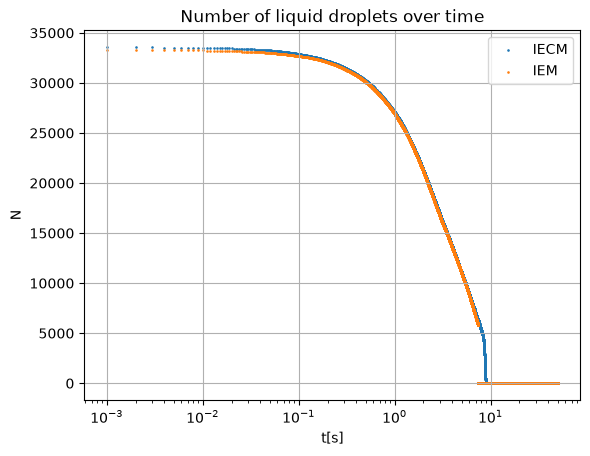

In [31]:
IECM = np.loadtxt("output/05-10-2026_2/NT_IECM.txt")
IEM = np.loadtxt("output/05-10-2026_1/NT_IEM.txt")
xaxis = np.arange(0,len(IECM)*1e-3,1e-3)
plt.scatter(x=xaxis,y=IECM, label = "IECM",marker='.',s = 3)
plt.scatter(x=xaxis,y=IEM, label = "IEM",marker='.',s = 3)
plt.legend()
plt.xscale('log')
plt.grid()
plt.xlabel("t[s]")
plt.ylabel("N")
plt.title("Number of liquid droplets over time")